In [1]:
from pathlib import Path
import importlib
import logging
import sys
import os

logging.basicConfig(
    format="%(levelname)s: %(message)s", stream=sys.stdout, level=logging.INFO
)
logger = logging.getLogger("__notebook__")

# Loading markov model directory as module into jupyter notebook
module_dir = Path(os.getcwd()).parent.resolve()
data_dir = module_dir / "data"

logger.info(f"module directory: {module_dir}")

if str(module_dir) not in sys.path:
    sys.path.insert(1, str(module_dir))
else:
    logger.info("Module path already inserted into system paths")

try:
    from model import markov_chain
    from model import probabilistic_analysis as psa
    from model import visualization
    from model import constants
    from model import utils

    # to apply changes in modules
    importlib.reload(markov_chain)
    importlib.reload(psa)
    importlib.reload(visualization)
    importlib.reload(constants)
    importlib.reload(utils)
except ModuleNotFoundError as e:
    logger.error(f"Unable to import module: {e.msg}")

INFO: module directory: /home/mohammad/projects/Thesis/hemophilia


In [2]:
# Model inputs
base_sample_size = 128
long_steps = constants.LONG_TERM_CYCLE_COUNTS
ssp = constants.START_SIMULATION_AGE_IN_WEEK

# Loading states name from excel sheet is deprecated, now on only generate within the code blocks
start_state = constants.START_STATE
primary_states = constants.PRIMARY_STATES
secondary_states = constants.SECONDARY_STATES
# NOTE:
# Transition matrix is dynamically generated through the *_psa functions as they sample from abr values
# To change in states need to update the psa worker functions as well to support new model schema
# NOTE:
# Newly suggested model structure:               switch
#                   [Healthy]                    ------>                     [Arthropathy]
#        |              |              |                           |              |              |
# [LT Bleeding] | [Hemarthrosis] | [Bleeding]               [LT Bleeding] | [Hemarthrosis] | [Bleeding]
#    |                  |                                          |
# [DEATH]         [Arthropathy]                                 [DEATH]
chains = {"primary": (primary_states, {}), "secondary": (secondary_states, {})}


# Define switch conditions
def arthropathy_switch_condition(step: int, state: str, chain: str, **kwargs) -> bool:
    """Determine if a switch to the secondary chain should occur based on the Arthropathy state."""
    return state == "Arthropathy" and chain == "primary"

switch_conditions = {"secondary": arthropathy_switch_condition}

In [3]:
weights = [utils.cal_body_weight(w, b=ssp) for w in range(long_steps)]
# Short term simulation
on_demand_inputs, on_demand_outputs = psa.markov_chains_psa_wrapper(
    strategy="on_demand",
    n_samples=base_sample_size,
    chains=chains,
    start_chain="primary",
    start_state="Healthy",
    steps=long_steps,
    switch_conditions=switch_conditions,
)

prophylaxis_inputs, prophylaxis_outputs = psa.markov_chains_psa_wrapper(
    strategy="prophylaxis",
    n_samples=base_sample_size,
    chains=chains,
    start_chain="primary",
    start_state="Healthy",
    steps=long_steps,
    switch_conditions=switch_conditions,
)

Text(0.5, 0, 'Age (year)')

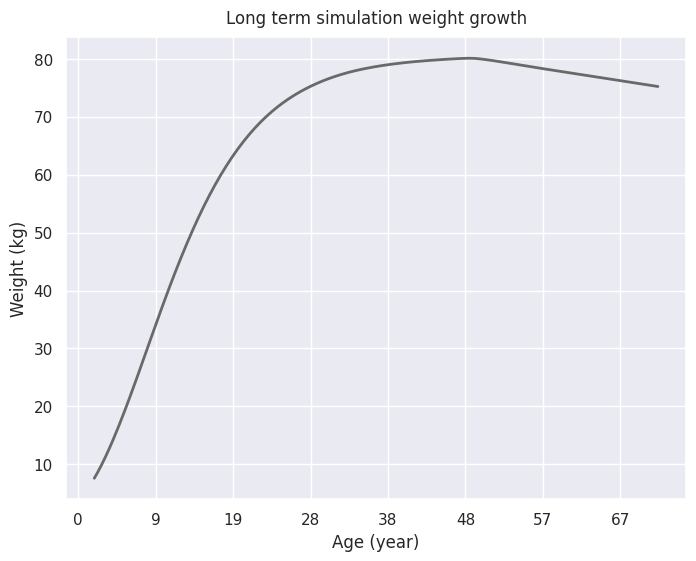

In [125]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
from scipy.interpolate import UnivariateSpline

pairs: dict[int, float] = {(i + ssp): weight for i, weight in enumerate(weights)}
x = np.array(list(pairs.keys()))
y = np.array(list(pairs.values()))
spline = UnivariateSpline(x, y, s=1.0)
x_smooth = np.linspace(min(x), max(x), 300)
y_smooth = spline(x_smooth)
def weeks_to_years(x, pos):
    return f'{int(round(x/52, 2))}'
fig, ax = plt.subplots(1,1, figsize=(8, 6))
ax.plot(x_smooth, y_smooth, color='dimgray', linestyle='-', linewidth=2)
ax.xaxis.set_major_formatter(FuncFormatter(weeks_to_years))
ax.set_title("Long term simulation weight growth", pad=10)
ax.set_ylabel("Weight (kg)")
ax.set_xlabel("Age (year)")

In [126]:
# ---- Debug cell ----
debug = False

# Graphs stores at outputs/figures/transitions
if debug:
    # on_demand simulation transition matrix graph
    for rate, inputs in enumerate(np.random.choice(on_demand_inputs, size=5)):
        chains = inputs["chains"]
        primary_matrix = chains["primary"][1]
        secondary_matrix = chains["secondary"][1]
        visualization.visualize_transition_matrix(
            matrix=primary_matrix,
            states=primary_states,
            title=f"on-demand-primary-{int(round(inputs['abr'],0))}-{int(round(inputs['ajbr'], 0))}",
        )
        visualization.visualize_transition_matrix(
            matrix=secondary_matrix,
            states=secondary_states,
            title=f"on-demand-secondary-{int(round(inputs['abr'],0))}-{int(round(inputs['ajbr'], 0))}",
        )
    # prophylaxis simulation transition matrix graph
    for rate, inputs in enumerate(np.random.choice(prophylaxis_inputs, size=5)):
        chains = inputs["chains"]
        primary_matrix = chains["primary"][1]
        secondary_matrix = chains["secondary"][1]
        visualization.visualize_transition_matrix(
            matrix=primary_matrix,
            states=primary_states,
            title=f"prophylaxis-primary-{int(round(inputs['abr'],0))}-{int(round(inputs['ajbr'], 0))}",
        )
        visualization.visualize_transition_matrix(
            matrix=secondary_matrix,
            states=secondary_states,
            title=f"prophylaxis-secondary-{int(round(inputs['abr'],0))}-{int(round(inputs['ajbr'], 0))}",
        )

In [127]:
import pandas as pd

df = pd.DataFrame(
    columns=[
        "on_demand_mean",
        "on_demand_median",
        "prophylaxis_mean",
        "prophylaxis_median",
    ],
)

on_demand_arthropathy = [
    op for op in on_demand_outputs if op.sequences.count("Arthropathy") > 0
]
prophylaxis_arthropathy = [
    op for op in prophylaxis_outputs if op.sequences.count("Arthropathy") > 0
]
# On_Demand results
od_consumption = [op.annual_factor_consumption for op in on_demand_outputs]
od_costs = [op.annual_factor_costs for op in on_demand_outputs]
od_qalys = [op.qaly for op in on_demand_outputs]
od_abrs = [op["abr"] for op in on_demand_inputs]

# Means
df.loc["annual iu", "on_demand_mean"] = np.mean(od_consumption)
df.loc["annual iu/kg", "on_demand_mean"] = np.mean(od_consumption) / np.mean(weights)
df.loc["annual costs ($)", "on_demand_mean"] = np.mean(od_costs)
df.loc["qaly", "on_demand_mean"] = np.mean(od_qalys)

# Medians
df.loc["annual iu", "on_demand_median"] = np.median(od_consumption)
df.loc["annual iu/kg", "on_demand_median"] = np.median(od_consumption) / np.median(
    weights
)
df.loc["annual costs ($)", "on_demand_median"] = np.median(od_costs)
df.loc["qaly", "on_demand_median"] = np.median(od_qalys)


# Prophylaxis results
pro_consumption = [op.annual_factor_consumption for op in prophylaxis_outputs]
pro_costs = [op.annual_factor_costs for op in prophylaxis_outputs]
pro_qalys = [op.qaly for op in prophylaxis_outputs]
pro_abrs = [op["abr"] for op in prophylaxis_inputs]

# Means
df.loc["annual iu", "prophylaxis_mean"] = np.mean(pro_consumption)
df.loc["annual iu/kg", "prophylaxis_mean"] = np.mean(pro_consumption) / np.mean(weights)
df.loc["annual costs ($)", "prophylaxis_mean"] = np.mean(pro_costs)
df.loc["qaly", "prophylaxis_mean"] = np.mean(pro_qalys)

# Medians
df.loc["annual iu", "prophylaxis_median"] = np.median(pro_consumption)
df.loc["annual iu/kg", "prophylaxis_median"] = np.median(pro_consumption) / np.median(
    weights
)
df.loc["annual costs ($)", "prophylaxis_median"] = np.median(pro_costs)
df.loc["qaly", "prophylaxis_median"] = np.median(pro_qalys)

# ICER value
d_costs = round(np.sum(pro_costs) - np.sum(od_costs), 2)
d_qalys = round(np.sum(pro_qalys) - np.sum(od_qalys), 2)
icer = round(d_costs / d_qalys, 2)

sample_size = len(on_demand_inputs)
# On demand arthropathy results
od_arthro_len = len(on_demand_arthropathy)
od_healthy_fraction = round(1 - (od_arthro_len / sample_size), 2)
# Prophylaxis arthropathy results
pro_arthro_len = len(prophylaxis_arthropathy)
pro_healthy_fraction = round(1 - (pro_arthro_len / sample_size), 2)

# Net monetary benefits
net_monetary_benefit = round((constants.WTP_THRESHOLD * (d_qalys/sample_size)) - (d_costs/sample_size), 2)


In [128]:
# Study reviewed from england journal suggests 93% of prophylaxis and 55% of on demand had normal joint MRI
# But the radio graphic results indicate 93% and 81% had no joint damage
def cue_message(icer, wtp):
    if icer < wtp:
        return "NOTE: ICER < WTP indicates intervention was cost effective"
    else:
        return "NOTE: ICER > WTP indicates intervention was not cost effective"


def nmb_message(nmb):
    if nmb < 0:
        return "Intervention was not cost effective"
    else:
        return "Intervention was cost effective"


print(
    f"""
    [Short Term]
    Simulation results for {int(long_steps/constants.WOY)} Years (2 - 72)
    {len(on_demand_inputs)} samples
    
    Number of simulations transitioned to chronic arthropathy:
    On demand: {len(on_demand_arthropathy)}, Prophylaxis: {len(prophylaxis_arthropathy)}
    Percentage of normal joints:
    On demand: {od_healthy_fraction}%, Prophylaxis: {pro_healthy_fraction}%
    
    {round(d_qalys / sample_size, 2)} qaly gained with ${round(d_costs / sample_size, 2):,} increase in cost of treatment
    Incremental cost effectiveness ratio: ${round(icer, 2):,}
    Willingness to pay threshold: ${round(constants.WTP_THRESHOLD, 2):,}
    {cue_message(icer, constants.WTP_THRESHOLD)}
    
    Net monetary benefit: ${net_monetary_benefit:.=,} ({nmb_message(net_monetary_benefit)})
    """
)
df.head()


    [Short Term]
    Simulation results for 70 Years (2 - 72)
    2816 samples
    
    Number of simulations transitioned to chronic arthropathy:
    On demand: 1384, Prophylaxis: 460
    Percentage of normal joints:
    On demand: 0.51%, Prophylaxis: 0.84%
    
    25.12 qaly gained with $128,926.85 increase in cost of treatment
    Incremental cost effectiveness ratio: $5,131.87
    Willingness to pay threshold: $14,314.2
    NOTE: ICER < WTP indicates intervention was cost effective
    
    Net monetary benefit: $230,685.96 (Intervention was cost effective)
    


,on_demand_mean,on_demand_median,prophylaxis_mean,prophylaxis_median
annual iu,5155.255753,1864.907143,265609.731463,263328.957143
annual iu/kg,77.06399,24.368315,3970.50054,3440.859234
annual costs ($),2551.888996,923.142565,131478.743918,130349.744084
qaly,10.64058,4.427067,35.763383,33.218558


Text(0, 0.5, 'QALY')

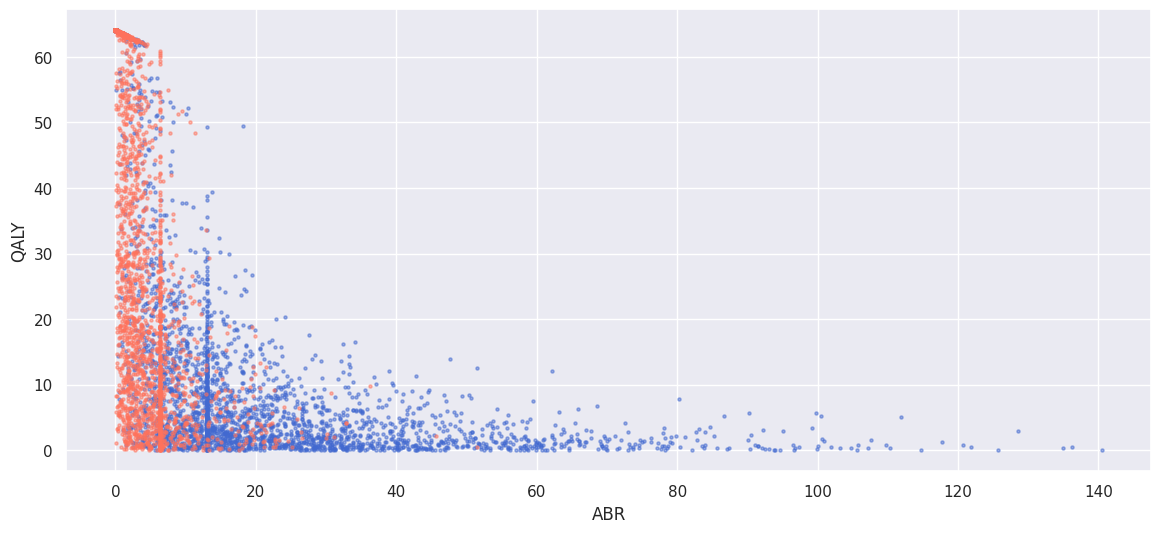

In [134]:
fig, ax = plt.subplots(1, 1, figsize=(14, 6))
scatter = ax.scatter(x=od_abrs, y=od_qalys, s=5, alpha=0.5, color="#4269D0")
scatter2 = ax.scatter(x=pro_abrs, y=pro_qalys, s=5, alpha=0.5, color="#FF725C")
ax.set_xlabel("ABR")
ax.set_ylabel("QALY")

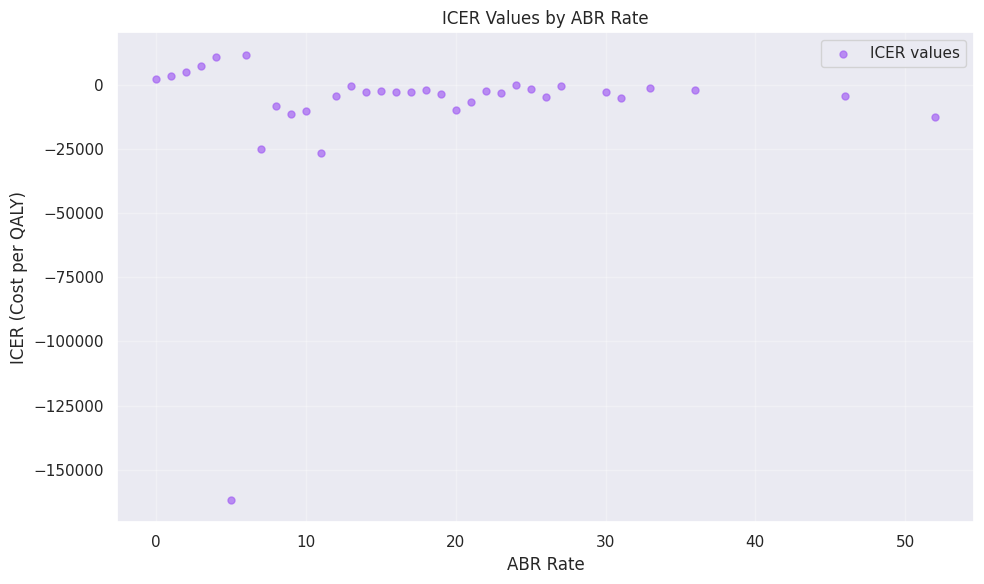

Number of valid ABR rates with ICER calculations: 34
ICER range: -161730.95 to 11670.22


In [ ]:
iter_size = int(np.max([op["abr"] for op in on_demand_inputs])) + 1

# On Demand
od_group = {i: [] for i in range(iter_size)}
od_abr_rounded = [int(round(_)) for _ in od_abrs]
for abr, qaly, cost in zip(od_abr_rounded, od_qalys, od_costs):
    od_group[abr].append((qaly, cost))
od_group_raw = od_group.copy()
od_group = {
    key: np.sum(value, axis=0) if value else np.array([0, 0])
    for key, value in od_group.items()
} # {abr: {total_qaly, total_costs}}

# Expected plot
# ICER = (Cost differences/Qaly differences)
#  ^
#  |
#  |
#  Y-Axes
#  X-Axes ---> ABR_ [1, 5, 12, 30]

# Prophylaxis
pro_group = {i: [] for i in range(iter_size)}
pro_abr_rounded = [int(round(_)) for _ in pro_abrs]
for abr, qaly, cost in zip(pro_abr_rounded, pro_qalys, pro_costs):
    pro_group[abr].append((qaly, cost))
pro_group_raw = pro_group.copy()
pro_group = {
    key: np.sum(value, axis=0) if value else np.array([0, 0])
    for key, value in pro_group.items()
}

# ICER per ABR
icer_data = []
valid_abr = []

# ICER Values
for rate in range(iter_size):
    # Check if both groups have non-zero data and QALY difference is not zero
    od_has_data = not np.array_equal(od_group[rate], np.array([0, 0]))
    pro_has_data = not np.array_equal(pro_group[rate], np.array([0, 0]))

    if od_has_data and pro_has_data:
        # Total Qaly / Total Costs
        qaly_diff = pro_group[rate][0] - od_group[rate][0]
        if qaly_diff != 0:  # Avoid division by zero
            icer = (pro_group[rate][1] - od_group[rate][1]) / qaly_diff
            icer_data.append(icer)
            valid_abr.append(rate)
        
        # Individual Qaly / Individual Cost
        
    

fig, ax = plt.subplots(1, 1, figsize=(10, 6))

ax.scatter(valid_abr, icer_data, color="#A463F2", s=25, alpha=0.7, label="ICER values")
ax.set_xlabel("ABR Rate")
ax.set_ylabel("ICER (Cost per QALY)")
ax.set_title("ICER Values by ABR Rate")
ax.grid(True, alpha=0.3)
ax.legend()

plt.tight_layout()
plt.show()

print(f"Number of valid ABR rates with ICER calculations: {len(valid_abr)}")
print(f"ICER range: {min(icer_data):.2f} to {max(icer_data):.2f}")

INFO: Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO: Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


/home/mohammad/projects/Thesis/.venv/lib/python3.10/site-packages/IPython/core/events.py:82: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  func(*args, **kwargs)
/home/mohammad/projects/Thesis/.venv/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


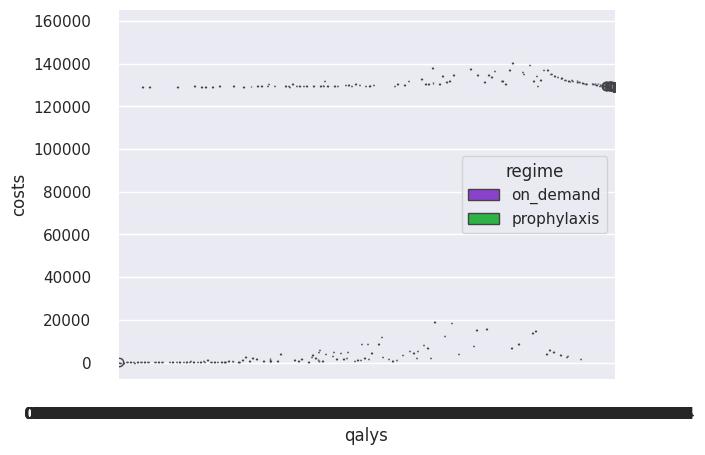

In [ ]:
on_demand_payload = []
for abr, pair in od_group_raw.items():  # 160 -> ABR -> list of qalys, list costs
    if not pair:
        continue
    try:
        for i in range(len(pair)):
            qaly = pair[i][0]
            cost = pair[i][1]
            on_demand_payload.append(["on_demand", abr, qaly, cost])
    except IndexError:
        continue

prophylaxis_payload = []
for abr, pair in pro_group_raw.items():
    if not pair:
        continue
    try:
        for i in range(len(pair)):
            qaly = pair[i][0]
            cost = pair[i][1]
            prophylaxis_payload.append(["prophylaxis", abr, qaly, cost])
    except IndexError:
        continue

on_demand_df = pd.DataFrame(
    on_demand_payload,
    columns=[
        "regime",
        "abr",
        "qalys",
        "costs",
    ],
)
prophylaxis_df = pd.DataFrame(
    prophylaxis_payload,
    columns=[
        "regime",
        "abr",
        "qalys",
        "costs",
    ],
)
df = pd.concat([on_demand_df, prophylaxis_df], ignore_index=True, sort=False)
#TODO: Sample for individual icer calculation
import seaborn as sns
sns.set_theme(style="ticks", palette="pastel")
sns.boxplot(data=df, hue="regime", x=df["qalys"], y=df["costs"], palette=["m", "g"])
sns.despine(offset=10, trim=True)
# Create legend with set location to top right

In [ ]:
# Value to report:
# Report no. of factor viii infusions [ ]
# Report no. of factor viii unit infused [ ]
# Report no. of factor viii unit infused per kg [ ]
# Report annual cost of factor viii / kg [ ]
# Report annual joint hemorrhages [ ]
# Report annual bleeding rate [ ]
# Report quality adjusted life year [ ]
# Report Incremental cost effectiveness ratio [ ]
# Report Net monetary benefit [√]